<a href="https://colab.research.google.com/github/souhirbenamor/EPF/blob/main/2025_Lasso_RegressionLARX_model_Bridging_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Raw data:
                     Date  Price  Demand Day-ahead DE  \
0 2018-12-31 00:00:00.000  10.07             41662.75   
1 2019-01-01 00:59:59.983  -4.08             40553.00   
2 2019-01-01 01:59:59.983  -9.91             40261.25   
3 2019-01-01 02:59:59.983  -7.41             40603.25   
4 2019-01-01 03:59:59.983 -12.55             40904.25   

   Wind and PV Day ahead (MWh/h)    Gas   Coal    CO2  
0                       25668.75  21.98  75.44  24.73  
1                       27384.00  21.98  75.44  24.73  
2                       29010.25  21.98  75.44  24.73  
3                       30359.25  21.98  75.44  24.73  
4                       31409.25  21.98  75.44  24.73  
Data after filtering (from 2019-01-01):
                         Price  Demand Day-ahead DE  \
Date                                                  
2019-01-01 00:59:59.983  -4.08             40553.00   
2019-01-01 01:59:59.983  -9.91             40261.25   
2019-01-01 02:59:59.983  -7.41             40603.25

<ipython-input-4-ceba9f6fdd0b>:107: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_forecast_raw = X_forecast_raw.fillna(method='ffill').fillna(method='bfill')
<ipython-input-4-ceba9f6fdd0b>:107: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X_forecast_raw = X_forecast_raw.fillna(method='ffill').fillna(method='bfill')


Insufficient data for 2024-12-31T00:00:00.000000000. Skipping.
Rolling forecast completed.
Forecast results shape: (17520, 1)
Test MSE: 1499.93


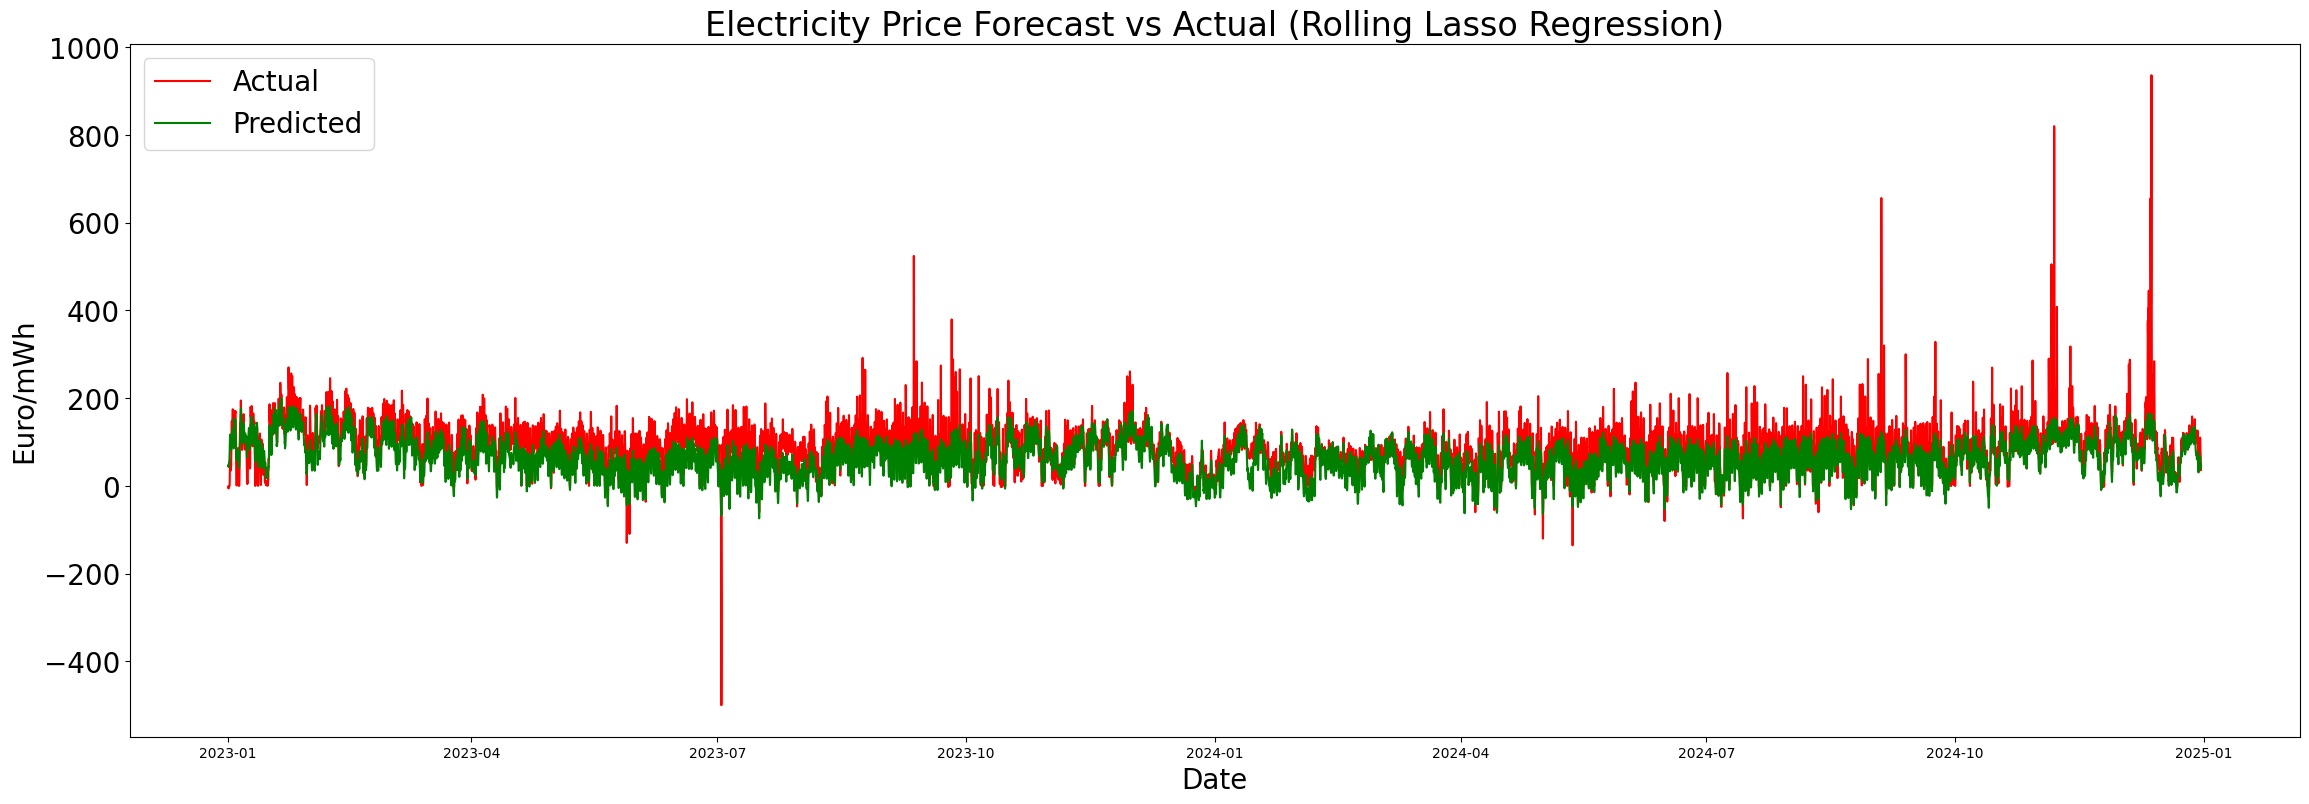

Forecast results saved to CSV and Excel.


In [ ]:
# -------------------------------------------------------------
# Step 0: Import Libraries and Set Random Seed
# -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import csv

# Set the seed for reproducibility
np.random.seed(42)

# -------------------------------------------------------------
# Step 1: Data Loading and Preprocessing
# -------------------------------------------------------------
# Load the Excel file (adjust file path as needed)
data = pd.read_excel('/content/EPF_data_Indiv.xlsx')

# Expected columns:
#  Date | Price | Demand Day-ahead DE | Wind and PV Day ahead (MWh/h) | Gas | Coal | CO2
print("Raw data:")
print(data.head())

# Remove duplicate date rows and convert "Date" to datetime
data.drop(data.loc[data['Date'].duplicated()].index, inplace=True)
data['Date'] = pd.to_datetime(data['Date'])

# Set "Date" as the index and drop the original column
data.set_index('Date', inplace=True)

# Filter data to only include records from 2019 onward (ensuring full day records)
data = data[data.index >= '2019-01-01']
print("Data after filtering (from 2019-01-01):")
print(data.head())

# (Optional) You could add a time-of-day feature if desired:
# data['Hour'] = data.index.hour

# -------------------------------------------------------------
# Step 2: Define Target, Features, and Year Splitting
# -------------------------------------------------------------
# According to the file:
#   Target: "Price"
#   Features: "Demand Day-ahead DE", "Wind and PV Day ahead (MWh/h)", "Gas", "Coal", "CO2"
target_column = "Price"
features_list = ["Demand Day-ahead DE", "Wind and PV Day ahead (MWh/h)", "Gas", "Coal", "CO2"]
print("Target column:", target_column)
print("Feature columns:", features_list)

# Get available years
unique_years = sorted(data.index.year.unique())
print("Unique years in data:", unique_years)

# Use the first 4 years (2019–2022) as training and the remaining years as test
train_years = [year for year in unique_years if year <= 2022]
test_years  = [year for year in unique_years if year > 2022]
print("Training years:", train_years)
print("Test years:", test_years)

# Split the data accordingly
train_data = data[data.index.year.isin(train_years)]
test_data  = data[data.index.year.isin(test_years)]
print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

# Initialize the rolling training sample with the initial training data.
updated_history = train_data.copy()

# -------------------------------------------------------------
# Step 3: Rolling Forecast Loop (Re-train Lasso Each Day)
# -------------------------------------------------------------
# We forecast one day (24 hourly observations) at a time.
# For each test day, we:
#   a) Re-fit scalers on updated_history and re-train the Lasso model.
#   b) Extract the test day's raw feature data.
#   c) Impute missing values if any.
#   d) Scale the test day's features using the scalers fitted on updated_history.
#   e) Predict (in scaled space), then inverse-transform predictions.
#   f) Create new training rows (raw features combined with forecasted target)
#      and append them to updated_history.
forecast_results = pd.DataFrame()

# Get unique test days (using just the date part of the index)
test_days = pd.to_datetime(test_data.index.date).unique()
test_days = np.sort(test_days)
print("Number of forecast days in test period:", len(test_days))

# Use a lower alpha to try to overcome constant forecasts
alpha_value = 0.001

for day in test_days:
    # a) Extract the raw features for this test day (expect 24 hourly rows)
    day_mask = test_data.index.normalize() == pd.Timestamp(day)
    X_forecast_raw = test_data.loc[day_mask, features_list].copy()

    # Check that we have 24 observations; if not, skip this day.
    if X_forecast_raw.empty or len(X_forecast_raw) < 24:
        print(f"Insufficient data for {day}. Skipping.")
        continue

    # b) Impute missing values (if any) for the test day's features
    if X_forecast_raw.isna().any().any():
        X_forecast_raw = X_forecast_raw.fillna(method='ffill').fillna(method='bfill')

    # c) Re-fit the scalers on the current training sample (updated_history)
    X_hist = updated_history[features_list].copy()
    y_hist = updated_history[target_column].copy()

    scaler_X = MinMaxScaler(feature_range=(-1,1))
    scaler_y = MinMaxScaler(feature_range=(-1,1))

    X_hist_scaled = pd.DataFrame(scaler_X.fit_transform(X_hist),
                                 index=X_hist.index,
                                 columns=X_hist.columns)
    y_hist_scaled = pd.DataFrame(scaler_y.fit_transform(y_hist.values.reshape(-1,1)),
                                 index=y_hist.index,
                                 columns=[target_column])

    # d) Re-train the Lasso model on the scaled updated training sample
    lasso_model = Lasso(alpha=alpha_value, random_state=42)
    lasso_model.fit(X_hist_scaled, y_hist_scaled.values.ravel())

    # e) Scale the test day features using the scaler fitted on updated_history
    X_forecast_scaled = pd.DataFrame(scaler_X.transform(X_forecast_raw),
                                     index=X_forecast_raw.index,
                                     columns=X_forecast_raw.columns)

    # Predict in scaled space and inverse-transform predictions to original scale
    y_forecast_scaled = lasso_model.predict(X_forecast_scaled)
    y_forecast = scaler_y.inverse_transform(y_forecast_scaled.reshape(-1,1))

    # Build a DataFrame for the forecast for this day (24 hourly predictions)
    df_forecast = pd.DataFrame({target_column: y_forecast.ravel()},
                               index=X_forecast_raw.index)

    # f) Update the training sample (rolling window):
    # Create new training rows by combining the raw features of the test day with the forecasted target,
    # then append these rows to updated_history.
    new_training_rows = X_forecast_raw.copy()
    new_training_rows[target_column] = df_forecast[target_column]
    updated_history = pd.concat([updated_history, new_training_rows]).sort_index()

    # Store this day's forecasts for later evaluation
    forecast_results = pd.concat([forecast_results, df_forecast])

print("Rolling forecast completed.")
print("Forecast results shape:", forecast_results.shape)

# -------------------------------------------------------------
# Step 4: Evaluation and Visualization
# -------------------------------------------------------------
# Align forecast_results with actual test targets (if available).
forecast_results = forecast_results.sort_index()
actual_test = test_data[[target_column]].loc[forecast_results.index]

# Combine actual and forecasted values
results = actual_test.copy()
results['predicted_price'] = forecast_results[target_column]

# Compute Mean Squared Error (MSE)
mse = mean_squared_error(results[target_column], results['predicted_price'])
print(f"Test MSE: {mse:.2f}")

# Plot actual vs. predicted prices
plt.figure(figsize=(28, 9))
plt.xlabel('Date', fontsize=20)
plt.ylabel('Euro/mWh', fontsize=20)
plt.plot(results[target_column], label='Actual', color='r')
plt.plot(results['predicted_price'], label='Predicted', color='g')
plt.tick_params(axis='y', labelsize=20)
plt.legend(prop={'size': 20})
plt.title('Electricity Price Forecast vs Actual (Rolling Lasso Regression)', fontsize=24)
plt.show()

# -------------------------------------------------------------
# Step 5: Save Forecast Results
# -------------------------------------------------------------
results.to_csv('Electricity_Price_Forecast_Results_Lasso_Rolling.csv', header=True,
               quoting=csv.QUOTE_NONE, escapechar=' ')
results.to_excel('Electricity_Price_Forecast_Results_Lasso_Rolling.xlsx', header=True)
print("Forecast results saved to CSV and Excel.")
